## 코랩 실행

- 윈도우 기준

In [1]:
!apt -qq -y install fonts-nanum
 
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
 
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font = fm.FontProperties(fname=fontpath, size=10)
fm._rebuild()
 
# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'
 
# Colab 의 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic') 

fonts-nanum is already the newest version (20170925-1).
0 upgraded, 0 newly installed, 0 to remove and 39 not upgraded.


In [2]:
# 구글드라이브 연동
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

# 구글 드라이브 파일 확인
!ls '/gdrive/My Drive/temp/final_data'

# 반복되는 드라이브 경로 변수화
drive_path = '/gdrive/My Drive/temp/final_data/'

Mounted at /gdrive
beauty_buy.csv	food_buy.csv  home_buy.csv  weather2018.csv  weather.csv
beauty_sns.csv	food_sns.csv  home_sns.csv  weather2019.csv


## 라이브러리 호출

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

In [4]:
food_buy = pd.read_csv(drive_path + 'food_buy.csv', encoding='cp949', index_col=0)
food_sns = pd.read_csv(drive_path + 'food_sns.csv', encoding='cp949', index_col=0)
beauty_buy = pd.read_csv(drive_path + 'beauty_buy.csv', encoding='cp949', index_col=0)
beauty_sns = pd.read_csv(drive_path + 'beauty_sns.csv', encoding='cp949', index_col=0)
home_buy = pd.read_csv(drive_path + 'home_buy.csv', encoding='cp949', index_col=0)
home_sns = pd.read_csv(drive_path + 'home_sns.csv', encoding='cp949', index_col=0)
weather = pd.read_csv(drive_path + 'weather.csv', encoding='cp949', index_col= 0)

In [49]:
weather2018 = pd.read_csv(drive_path + 'weather2018.csv', encoding='cp949', index_col= 0)
weather2019 = pd.read_csv(drive_path + 'weather2019.csv', encoding='cp949', index_col= 0)

In [5]:
# datetime으로 변경
food_buy['date'] = pd.to_datetime(food_buy['date'])
food_sns['date'] = pd.to_datetime(food_sns['date'])
beauty_buy['date'] = pd.to_datetime(beauty_buy['date'])
beauty_sns['date'] = pd.to_datetime(beauty_sns['date'])
home_buy['date'] = pd.to_datetime(home_buy['date'])
home_sns['date'] = pd.to_datetime(home_sns['date'])
weather['date'] = pd.to_datetime(weather['date'])
weather2018['date'] = pd.to_datetime(weather2018['date'])
weather2019['date'] = pd.to_datetime(weather2019['date'])

## 이상기후 선별 및 데이터 분석

- 기온이 따뜻한 여름에는 생각보다 온라인 구매량이 많지 않고 제일 추운 1월에는 온라인 구매량이 가장 많다
- SNS는 기온이 높고 사람들이 가장 활발한 시기인 7,8월에 SNS활동양이 많다.

In [9]:
hot = weather[weather['max_ta'] >= 33]
jangma = weather[((weather['date'] <= "2018-07-11") & (weather['date'] >= '2018-06-26')) | ((weather['date'] <= "2019-07-29") & (weather['date'] >= "2019-06-26"))]
snow = weather[weather['min_ta'] < -12]
air = weather[weather['미세먼지'] >= 81]

- 식품

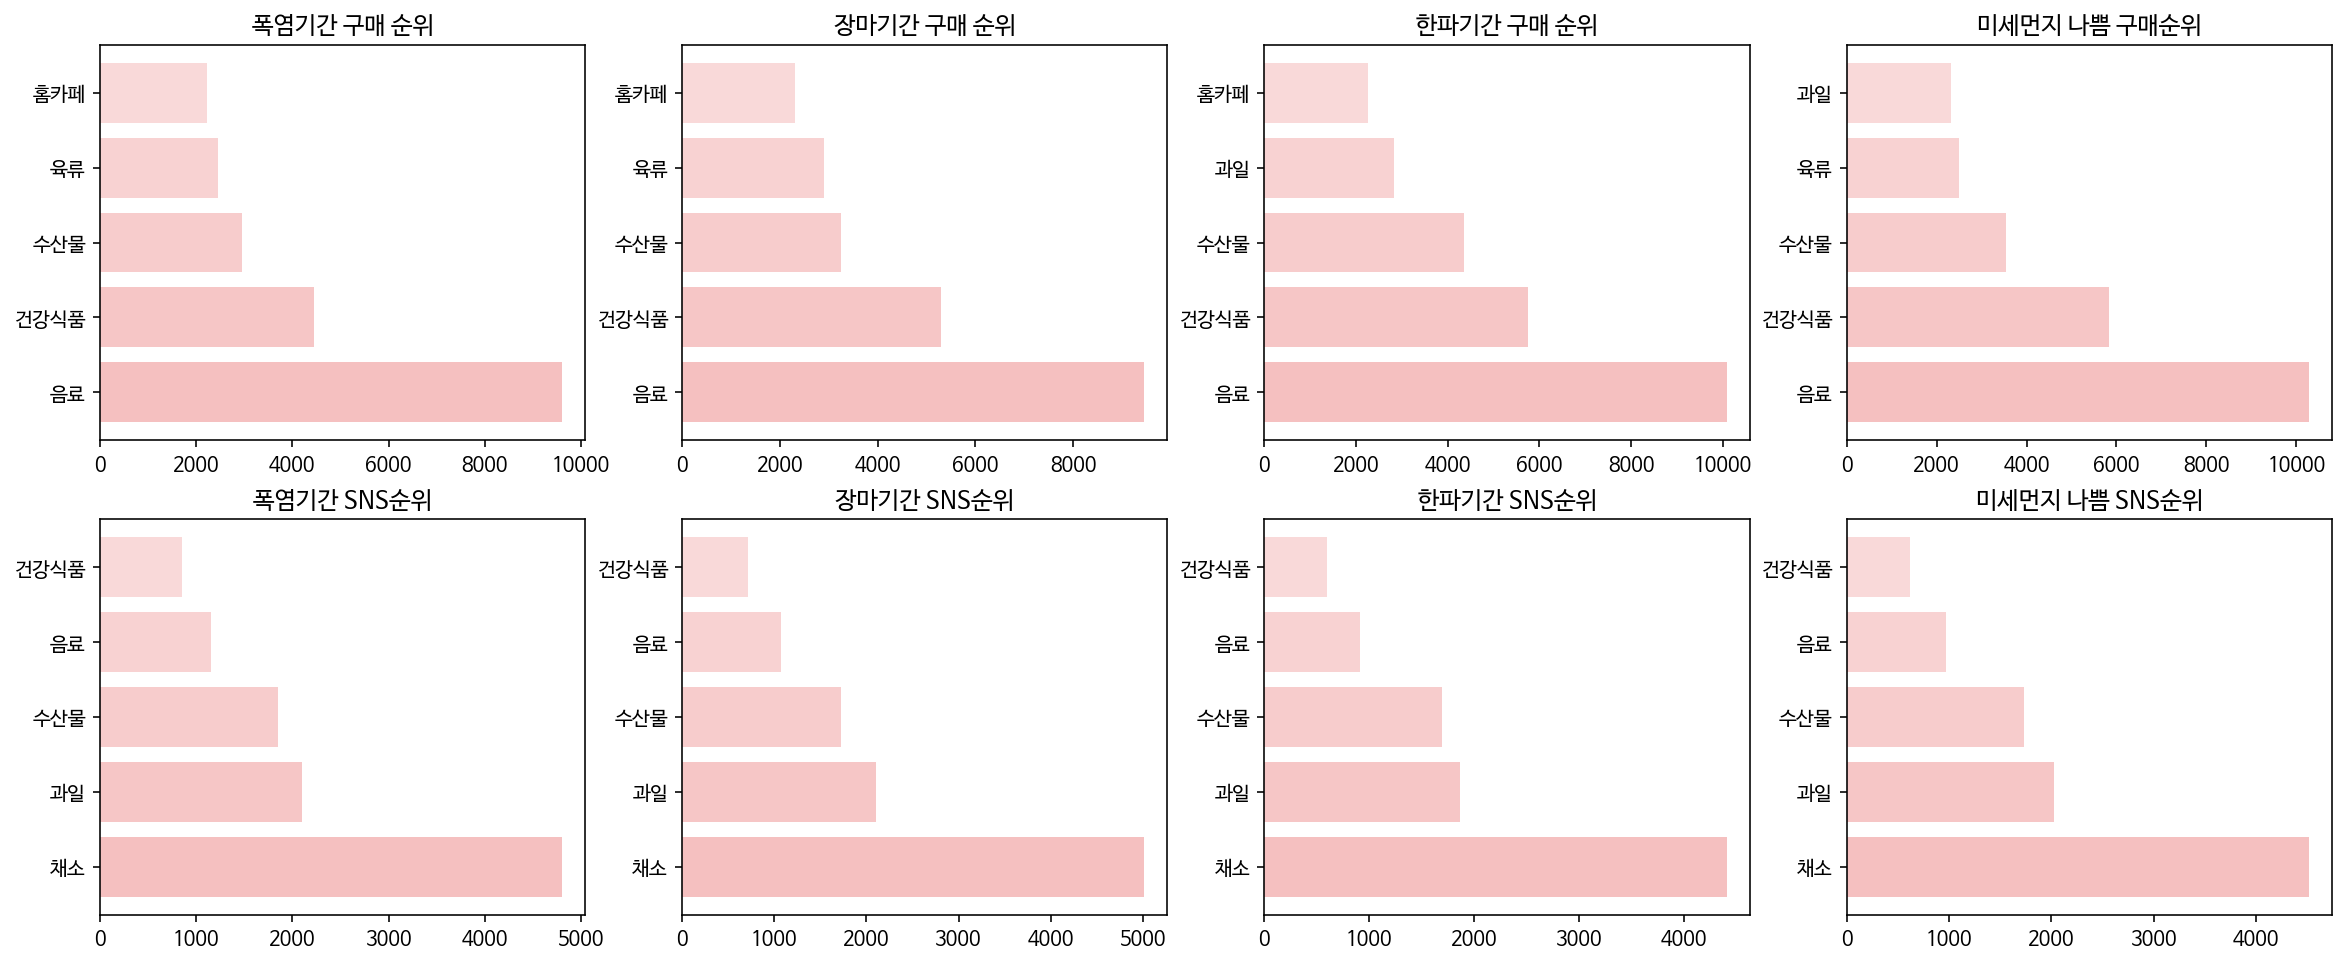

In [33]:
colors = ['#f5c0c0', '#f6c6c6', '#f7cccc','#f8d2d2', '#f9d9d9']
w = list(hot['date'])
plt.figure(figsize=(20, 8))

plt.subplot(241)
food = food_buy.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]
plt.barh(food.index, food.qty.values, color=colors)
plt.title('폭염기간 구매 순위')

plt.subplot(245)
food = food_sns.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(food.index, food.cnt.values, color=colors)
plt.title('폭염기간 SNS순위')

w = list(jangma['date'])
food = food_buy.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(242)
plt.barh(food.index, food.qty.values, color=colors)
plt.title("장마기간 구매 순위")

plt.subplot(246)
food = food_sns.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(food.index, food.cnt.values, color=colors)
plt.title('장마기간 SNS순위')

w = list(snow['date'])
food = food_buy.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(243)
plt.barh(food.index, food.qty.values, color=colors)
plt.title("한파기간 구매 순위")

plt.subplot(247)
food = food_sns.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(food.index, food.cnt.values, color=colors)
plt.title("한파기간 SNS순위")

w = list(air['date'])
food = food_buy.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(244)
plt.barh(food.index, food.qty.values, color=colors)
plt.title("미세먼지 나쁨 구매순위")


plt.subplot(248)
food = food_sns.groupby(['date','mid']).sum()
food = food.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(food.index, food.cnt.values, color=colors)
plt.title("미세먼지 나쁨 SNS순위")

plt.show()

- 뷰티

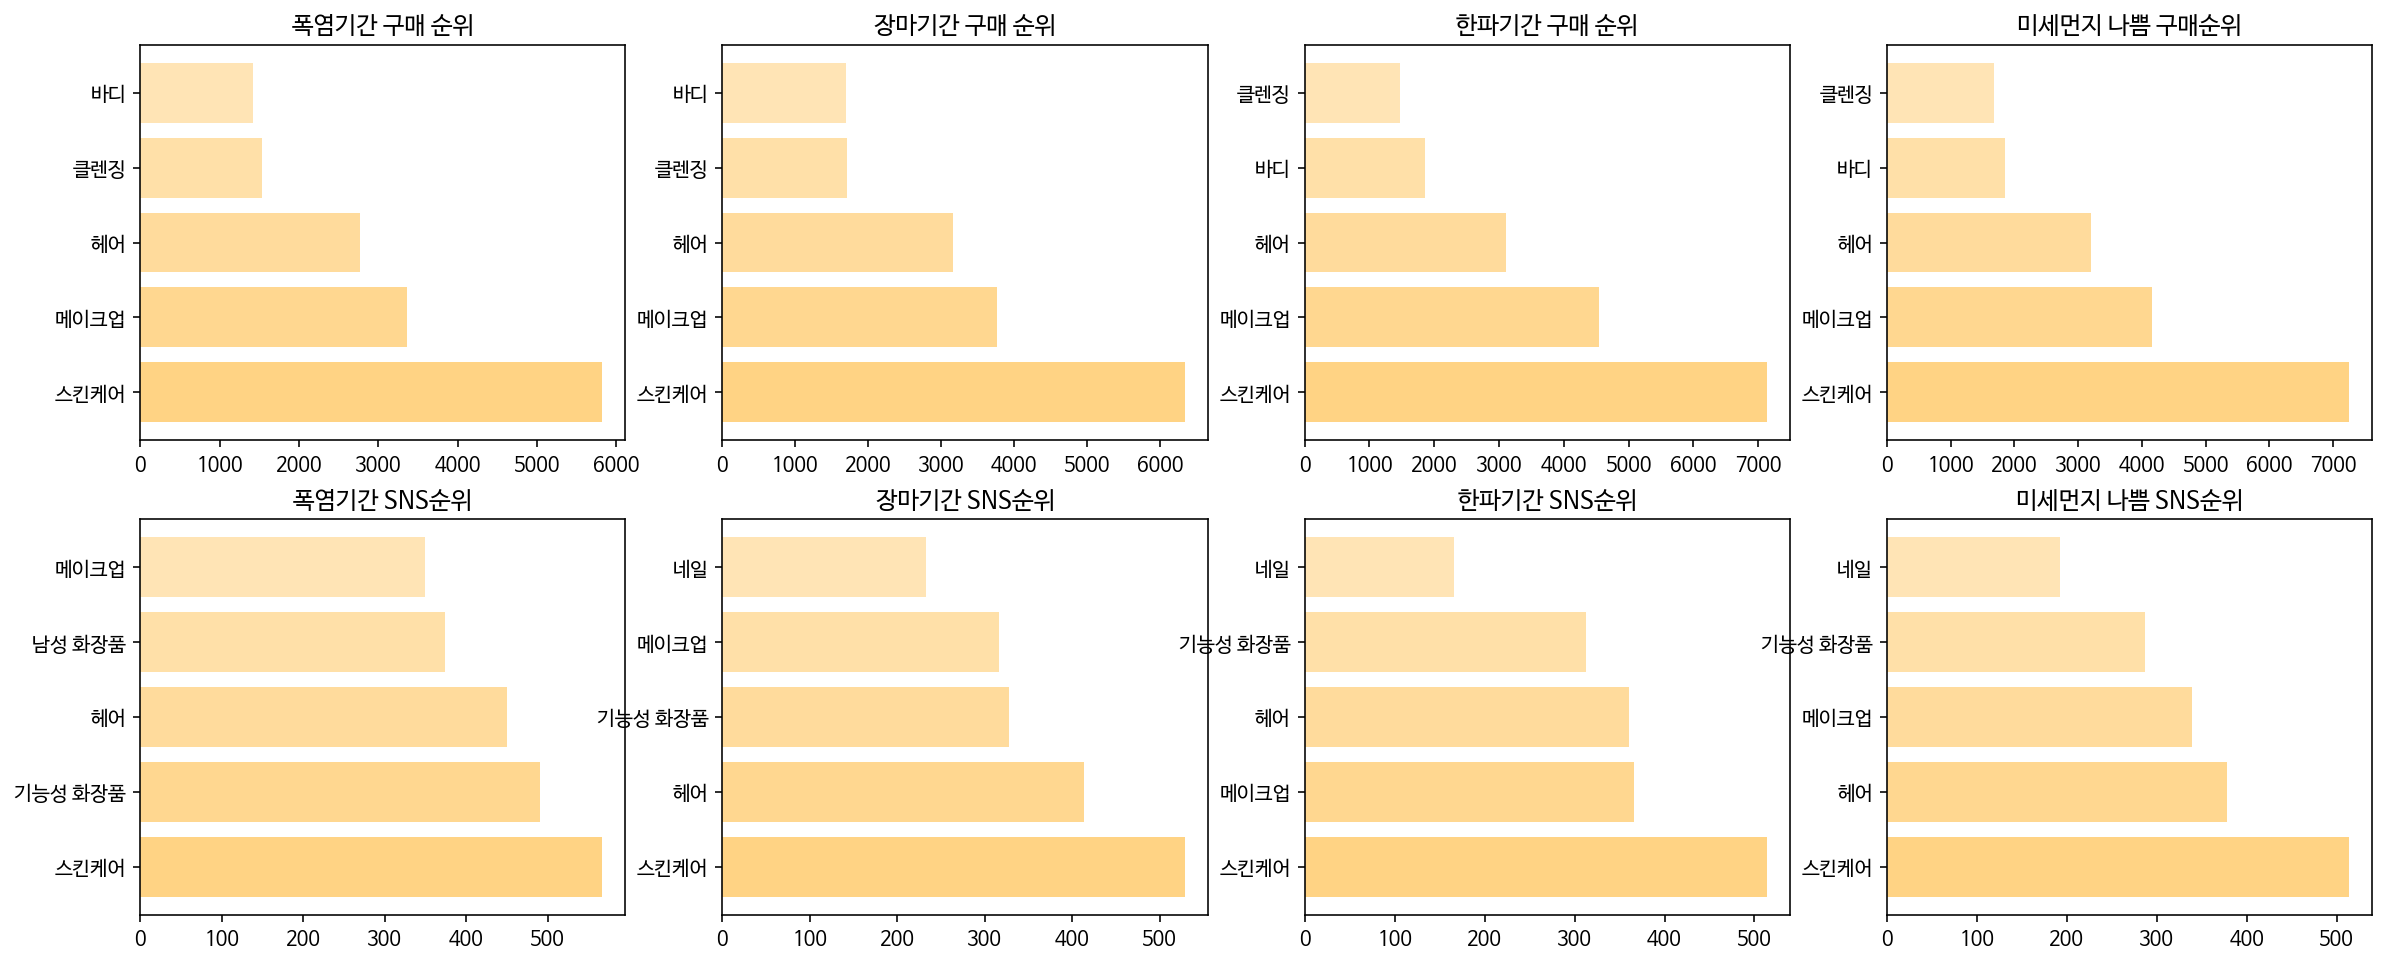

In [34]:
colors = ['#ffd384', '#ffd790', '#ffdb9c','#ffe0a8', '#ffe4b5']
w = list(hot['date'])
plt.figure(figsize=(20, 8))

plt.subplot(241)
beauty = beauty_buy.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]
plt.barh(beauty.index, beauty.qty.values, color=colors)
plt.title('폭염기간 구매 순위')

plt.subplot(245)
beauty = beauty_sns.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(beauty.index, beauty.cnt.values, color=colors)
plt.title('폭염기간 SNS순위')

w = list(jangma['date'])
beauty = beauty_buy.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(242)
plt.barh(beauty.index, beauty.qty.values, color=colors)
plt.title("장마기간 구매 순위")

plt.subplot(246)
beauty = beauty_sns.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(beauty.index, beauty.cnt.values, color=colors)
plt.title('장마기간 SNS순위')

w = list(snow['date'])
beauty = beauty_buy.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(243)
plt.barh(beauty.index, beauty.qty.values, color=colors)
plt.title("한파기간 구매 순위")

plt.subplot(247)
beauty = beauty_sns.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(beauty.index, beauty.cnt.values, color=colors)
plt.title("한파기간 SNS순위")

w = list(air['date'])
beauty = beauty_buy.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(244)
plt.barh(beauty.index, beauty.qty.values, color=colors)
plt.title("미세먼지 나쁨 구매순위")


plt.subplot(248)
beauty = beauty_sns.groupby(['date','mid']).sum()
beauty = beauty.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(beauty.index, beauty.cnt.values, color=colors)
plt.title("미세먼지 나쁨 SNS순위")

plt.show()

- 가전

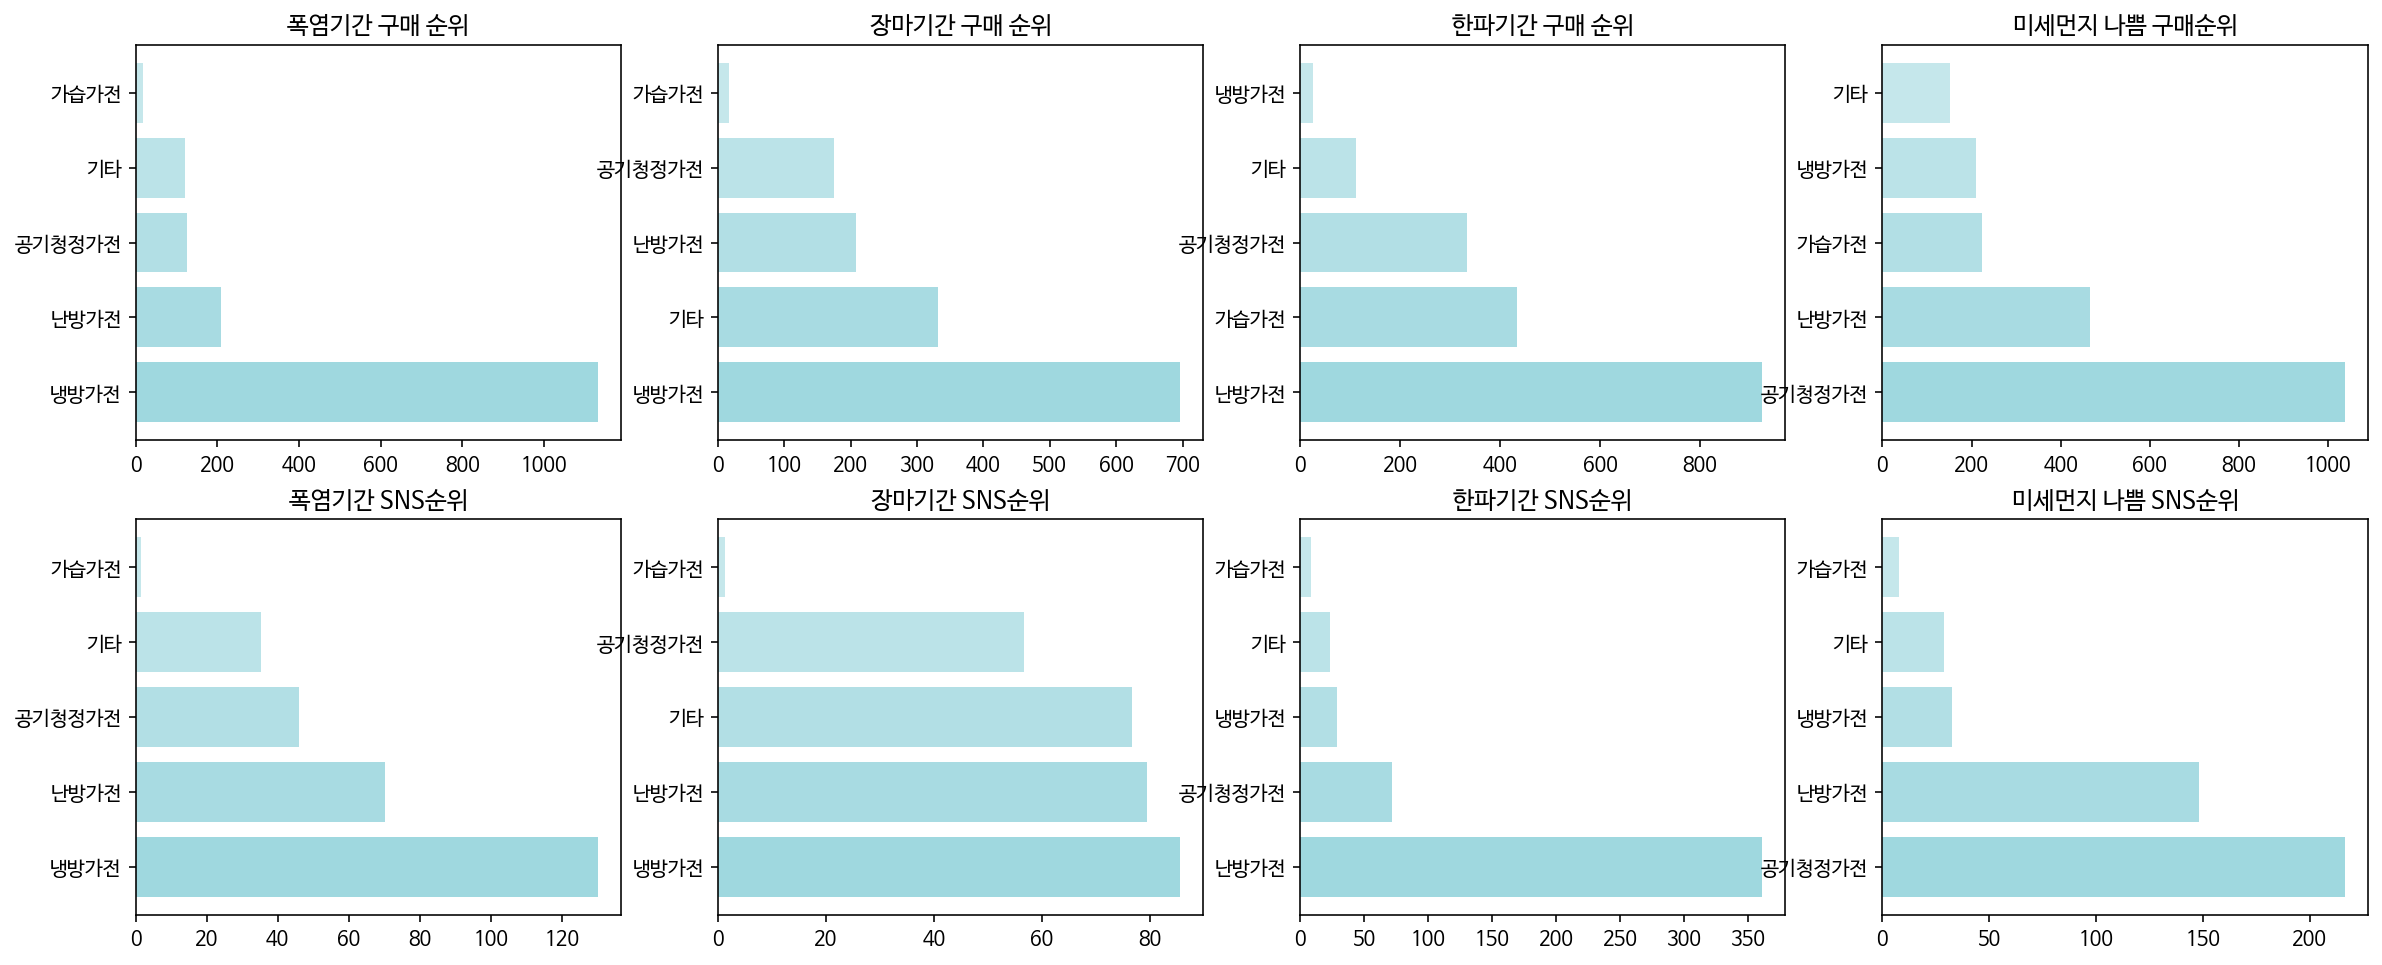

In [35]:
colors = ['#9fd8df', '#a8dbe2', '#b2dfe5','#bbe3e8', '#c5e7eb']
w = list(hot['date'])
plt.figure(figsize=(20, 8))

plt.subplot(241)
home = home_buy.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]
plt.barh(home.index, home.qty.values, color=colors)
plt.title('폭염기간 구매 순위')

plt.subplot(245)
home = home_sns.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(home.index, home.cnt.values, color=colors)
plt.title('폭염기간 SNS순위')

w = list(jangma['date'])
home = home_buy.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(242)
plt.barh(home.index, home.qty.values, color=colors)
plt.title("장마기간 구매 순위")

plt.subplot(246)
home = home_sns.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(home.index, home.cnt.values, color=colors)
plt.title('장마기간 SNS순위')

w = list(snow['date'])
home = home_buy.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(243)
plt.barh(home.index, home.qty.values, color=colors)
plt.title("한파기간 구매 순위")

plt.subplot(247)
home = home_sns.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(home.index, home.cnt.values, color=colors)
plt.title("한파기간 SNS순위")

w = list(air['date'])
home = home_buy.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='qty', ascending=False)[:5]

plt.subplot(244)
plt.barh(home.index, home.qty.values, color=colors)
plt.title("미세먼지 나쁨 구매순위")


plt.subplot(248)
home = home_sns.groupby(['date','mid']).sum()
home = home.reset_index().query('date in @w').groupby(['mid']).mean().sort_values(by='cnt', ascending=False)[:5]
plt.barh(home.index, home.cnt.values, color=colors)
plt.title("미세먼지 나쁨 SNS순위")

plt.show()

## 머신러닝 예측 데이터 만들기

In [36]:
def newdata(data):
    x = data.groupby(['date', 'mid']).sum().unstack()
    y = pd.DataFrame(x['qty'][:].values, columns=x['qty'][:].columns.tolist())
    y.insert(0, 'date', value=x.index)
    y.dropna(axis=1, inplace=True)
    return y

new_food = newdata(food_buy)
new_home = newdata(home_buy)
new_beauty = newdata(beauty_buy)

In [37]:
def model_check(data,weather, name):
    df = data.copy()
    df_wea = weather.copy()
    quan25 = np.percentile(data[name].values, 25)
    quan75 = np.percentile(data[name].values, 75)

    iqr = (quan75 - quan25) * 1.5

    lowest = quan25 - iqr
    highest = quan75 + iqr

    out = data[name][(data[name] < lowest) | (data[name] > highest)].index

    df.drop(out, axis=0, inplace=True)
    df_wea.drop(out, axis=0, inplace=True)

    res = pd.merge(df, df_wea, on='date')
    res = res[['date', name, 'avg_ta', 'max_ta', 'min_ta','avg_rhm', '미세먼지']]
    return res

health = model_check(new_food, weather, '건강식품')
fruit = model_check(new_food, weather, '과일')
fish = model_check(new_food, weather, '수산물')
meat = model_check(new_food, weather, '육류')
drink = model_check(new_food, weather, '음료')
veg = model_check(new_food, weather, '채소')
cafe = model_check(new_food, weather, '홈카페')

In [98]:
functional = model_check(new_beauty, weather, '기능성 화장품')
man = model_check(new_beauty, weather, '남성 화장품')
nail = model_check(new_beauty, weather, '네일')
body = model_check(new_beauty, weather, '바디')
make = model_check(new_beauty, weather, '메이크업')
skin = model_check(new_beauty, weather, '스킨케어')
clean = model_check(new_beauty, weather, '클렌징')

In [39]:
airhome = model_check(new_home, weather, '공기청정가전')
humhome = model_check(new_home, weather, '가습가전')
hothome = model_check(new_home, weather, '난방가전')
coldhome = model_check(new_home, weather, '냉방가전')

In [88]:
test1 = weather[['avg_ta', 'max_ta', 'min_ta', 'avg_rhm', '미세먼지']]

## 예측

In [96]:
def model_make_food(x, name):
    X_train = x.iloc[:,2:]
    y_train = x.iloc[:,1]
    X_test = test1
    y_test = new_food[name]

    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    test_lr = model_lr.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    model_dt.fit(X_train, y_train)
    test_lr = model_dt.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
    model_rf.fit(X_train, y_train)
    test_lr = model_rf.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_xgb = xgb.XGBClassifier(max_depth=5, learning_rate=0.01, n_estimators=100)
    model_xgb.fit(X_train, y_train)
    test_lr = model_xgb.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

print('건강식품')
model_make_food(health, '건강식품')

print()
print('과일')
model_make_food(fruit, '과일')

print()
print('수산물')
model_make_food(fish, '수산물')

print()
print('육류')
model_make_food(meat, '육류')

건강식품
1525.8179873166644
2206.124820112817
1721.4788632778298
1715.4298506796306

과일
681.9337797139929
916.6393100110503
728.0728079654054
839.3890774174222

수산물
888.9387599840173
1395.4793741082824
865.0962690906259
1011.443852002386

육류
730.9514943934204
1212.668052469204
770.6519531388423
939.5147858744493


In [100]:
def model_make_beauty(x, name):
    X_train = x.iloc[:,2:]
    y_train = x.iloc[:,1]
    X_test = test1
    y_test = new_beauty[name]

    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    test_lr = model_lr.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    model_dt.fit(X_train, y_train)
    test_lr = model_dt.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
    model_rf.fit(X_train, y_train)
    test_lr = model_rf.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_xgb = xgb.XGBClassifier(max_depth=5, learning_rate=0.01, n_estimators=100)
    model_xgb.fit(X_train, y_train)
    test_lr = model_xgb.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

print("클렌징")
model_make_beauty(clean, '클렌징')

print()
print("스킨케어")
model_make_beauty(skin,'스킨케어')

print()
print('기능성 화장품')
model_make_beauty(functional,'기능성 화장품')

print()
print("남성 화장품")
model_make_beauty(man,'남성 화장품')

클렌징
392.6620613701379
501.8249708512551
396.39819297930745
432.9341118524613

스킨케어
1295.6211351275392
1938.1513611248572
1383.523530798798
1457.4543151748935

기능성 화장품
220.7978369071772
266.44988991481387
242.68671106186963
256.22094489471334

남성 화장품
106.62506970497829
139.3026566041951
109.72077886648678
118.168436784341


In [97]:
def model_make_home(x, name):
    X_train = x.iloc[:,2:]
    y_train = x.iloc[:,1]
    X_test = test1
    y_test = new_home[name]

    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    test_lr = model_lr.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    model_dt.fit(X_train, y_train)
    test_lr = model_dt.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
    model_rf.fit(X_train, y_train)
    test_lr = model_rf.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

    model_xgb = xgb.XGBClassifier(max_depth=5, learning_rate=0.01, n_estimators=100)
    model_xgb.fit(X_train, y_train)
    test_lr = model_xgb.predict(X_test)
    RMSE = mean_squared_error(y_test.values, test_lr) ** 0.5
    print(RMSE)

print("냉방가전")
model_make_home(coldhome, '냉방가전')

print()
print("공기청정가전")
model_make_home(airhome, '공기청정가전')

print()
print("가습가전")
model_make_home(humhome, '가습가전')

print()
print("난방가전")
model_make_home(hothome, '난방가전')

냉방가전
358.6852521795795
500.277988475832
422.58476494266074
498.5873812205126

공기청정가전
407.83933390315474
454.2444094996039
418.19753803904416
429.0871977671569

가습가전
161.34114318160155
223.91922467283194
222.31952816327163
213.19990619134896

난방가전
460.83561053273826
655.1871645170907
552.7843308545895
568.2733376653966
